# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/praveenadanthapally/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research question

This project asks whether search-performance signals can be used to rank content pages for human review and identify pages with measurable opportunity for improved click-through performance.

The practical decision is not whether a page should automatically be changed. Instead, the goal is to produce a prioritized review queue that helps a content or SEO practitioner decide which pages deserve attention first.

The analysis therefore treats the model as **decision-support**, not as an automated content optimizer. A high score indicates that a page is worth investigating; it does not guarantee that changing the page will improve future search performance.


In [16]:
# Capstone Section 1 — Research question

research_question = (
    "Can search-performance signals be used to rank content pages "
    "for human review and identify pages with measurable CTR opportunity?"
)

decision_supported = (
    "The analysis supports prioritizing pages for human review. "
    "It does not automatically decide which pages should be changed "
    "or guarantee that a refresh will improve future performance."
)

print("Research question")
print("-----------------")
print(research_question)

print("\nDecision supported")
print("------------------")
print(decision_supported)

Research question
-----------------
Can search-performance signals be used to rank content pages for human review and identify pages with measurable CTR opportunity?

Decision supported
------------------
The analysis supports prioritizing pages for human review. It does not automatically decide which pages should be changed or guarantee that a refresh will improve future performance.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Data source and scope

This capstone uses the **FlyRank ML Internship dataset**, a large-scale anonymized search-performance dataset containing production-style content and search signals.

The analysis uses the internship warehouse release and the content/search-performance data used in the earlier weekly assignments. The working analysis is performed at the content-page observation level using aggregated search-performance signals.

The main signals used include:

* Average search position
* Search impressions
* Current CTR
* Historical/content-performance signals available before the recommendation point
* Model-derived predicted future CTR
* CTR opportunity used to prioritize pages for review

The data was restricted to fields needed for the ranking and recommendation task. Client names, private search queries, identifiable URLs, and other identifying information were excluded from the public-facing paper.

The earlier analysis covered a limited observed date window in the working sample rather than claiming that every row in the full dataset was used for model evaluation. The capstone therefore reports results from the evaluated sample and validation setup, not from the entire 79-million-row dataset.

### Exclusions

I excluded or avoided using:

1. **Client-identifying information** — to keep the analysis public-safe.
2. **Private queries and URLs** — because they are not necessary for demonstrating the ranking methodology.
3. **Identifier-like fields as predictive features** — to reduce the risk of memorization or leakage.
4. **Target-derived information that would reveal the outcome** — to avoid target leakage.
5. **Future information unavailable at the recommendation point** — to keep the prediction setup temporally meaningful.

The dataset is used for **research and decision-support**, not to make claims about individual clients or guarantee performance for unseen websites.


In [17]:
# Section 2 — Data scope checks

data_summary = {
    "Dataset": "FlyRank ML Internship dataset",
    "Analysis grain": "Content-page observation",
    "Public-safe": True,
    "Private queries included": False,
    "Client-identifying information included": False,
    "Identifier features used for prediction": False,
}

print("Data scope")
print("----------")

for key, value in data_summary.items():
    print(f"{key}: {value}")

Data scope
----------
Dataset: FlyRank ML Internship dataset
Analysis grain: Content-page observation
Public-safe: True
Private queries included: False
Client-identifying information included: False
Identifier features used for prediction: False


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Methodology

The analysis is designed as a ranking and decision-support task rather than a causal prediction of guaranteed future performance.

**Assumptions**

The model assumes that the search-performance signals available at the recommendation point contain useful information for prioritizing pages for human review. The resulting ranking is treated as directional evidence, not as a guarantee that a page will improve after an intervention.

**Features**

The model uses search-performance signals available in the working dataset, including average search position, impressions, and current CTR. Identifier-like fields such as client IDs, page IDs, URLs, queries, and keywords are not used as predictive features.

**Label definition**

The ranking target represents the page-level performance outcome used in the Week-5 modeling workflow. The model produces a predicted future CTR signal, which is then used together with observed search-performance signals to identify pages that may deserve human review.

**Baseline**

The Week-4 baseline achieved an NDCG of **0.4391**. The Week-5 Random Forest achieved an NDCG of **0.4629** on the original evaluation setup.

**Validation design**

The original Week-5 result was followed by a stricter validation audit in Week 6. A grouped split by client was used so that the training and evaluation sets contained different clients.

The grouped validation produced:

* Training clients: **7**
* Test clients: **2**
* Client overlap: **0**
* Honest grouped-split NDCG: **0.4000**

This lower score is treated as evidence that the original result may have been optimistic under the less strict evaluation setup. The grouped result is therefore the more conservative validation signal.

**Leakage checks**

The final feature set was checked for:

* Direct target inclusion
* Future information
* Target-derived features
* Identifier-like predictive features
* Client overlap between training and test sets

The audit found no direct target inclusion in the feature set, no identifier-like predictive features in the final working feature list, and **0 client overlap** between the grouped training and test sets.

These checks support using the model as a ranking aid, while not establishing that the recommendations have a causal effect on future search performance.


In [18]:
# Section 3 — Methodology checks

methodology_checks = {
    "Week-4 baseline NDCG": 0.4391,
    "Week-5 Random Forest NDCG": 0.4629,
    "Week-6 honest grouped NDCG": 0.4000,
    "Training clients": 7,
    "Test clients": 2,
    "Client overlap": 0,
    "Target in feature set": False,
    "Identifier-like predictive features": False,
}

print("Methodology validation checks")
print("-----------------------------")

for key, value in methodology_checks.items():
    print(f"{key}: {value}")

Methodology validation checks
-----------------------------
Week-4 baseline NDCG: 0.4391
Week-5 Random Forest NDCG: 0.4629
Week-6 honest grouped NDCG: 0.4
Training clients: 7
Test clients: 2
Client overlap: 0
Target in feature set: False
Identifier-like predictive features: False


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Results

The model was first evaluated under the original Week-5 setup and then tested under a stricter grouped validation design.

The Week-4 baseline produced an NDCG of **0.4391**, while the Week-5 Random Forest produced **0.4629** on the original evaluation setup. This is an observed improvement of **0.0238 NDCG points** over the baseline on that setup.

However, the stricter Week-6 grouped validation produced an NDCG of **0.4000**. The grouped result is lower than both the Week-4 baseline and the original Week-5 score, indicating that the apparent improvement was not fully stable when evaluation was performed across unseen clients.

For the final paper, the results are therefore presented conservatively:

* **Week-4 baseline:** 0.4391
* **Week-5 Random Forest:** 0.4629
* **Week-6 honest grouped validation:** 0.4000

The Week-5 result is a measured directional improvement under the original evaluation setup, while the grouped result provides a more conservative estimate of generalization. The model is consequently used as **decision-support for ranking pages for human review**, not as evidence of guaranteed future CTR improvement.


Results comparison
------------------
                          Method   NDCG
                 Week-4 baseline 0.4391
            Week-5 Random Forest 0.4629
Week-6 honest grouped validation 0.4000

Observed Week-5 improvement over baseline: 0.0238


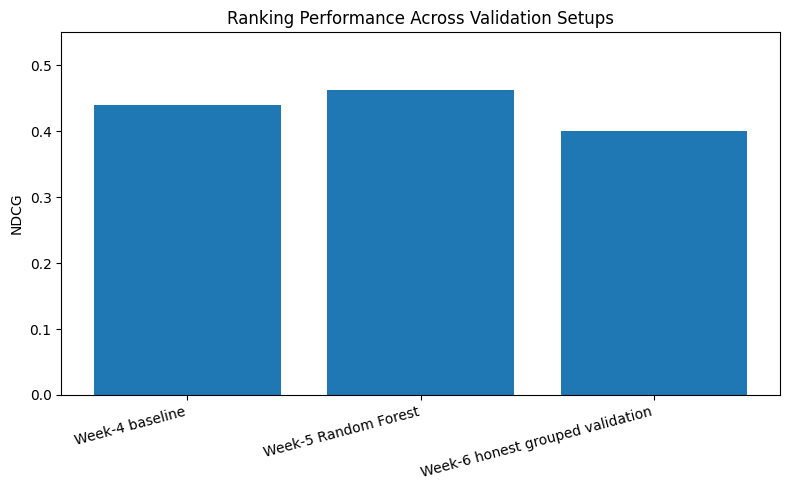


Chart saved: work/outputs/w07_ndcg_comparison.png


In [19]:
# Section 4 — Results comparison and chart

import pandas as pd
import matplotlib.pyplot as plt
import os

results = pd.DataFrame({
    "Method": [
        "Week-4 baseline",
        "Week-5 Random Forest",
        "Week-6 honest grouped validation"
    ],
    "NDCG": [
        0.4391,
        0.4629,
        0.4000
    ]
})

print("Results comparison")
print("------------------")
print(results.to_string(index=False))

baseline_ndcg = 0.4391
week5_ndcg = 0.4629

observed_difference = week5_ndcg - baseline_ndcg

print("\nObserved Week-5 improvement over baseline:",
      round(observed_difference, 4))

# Chart for the paper
plt.figure(figsize=(8, 5))
plt.bar(results["Method"], results["NDCG"])
plt.ylabel("NDCG")
plt.title("Ranking Performance Across Validation Setups")
plt.ylim(0, 0.55)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()

chart_path = "work/outputs/w07_ndcg_comparison.png"

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(chart_path), exist_ok=True)

plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()

print("\nChart saved:", chart_path)

## 5. Limitations

*What this work cannot claim.*

### Limitations

This analysis has several important limitations.

1. **The evaluation sample is limited.** The reported scores come from the working evaluation setup and should not be interpreted as performance across every row in the full FlyRank dataset.

2. **The grouped validation score is lower.** The Week-5 Random Forest achieved an NDCG of 0.4629 under the original setup, while the stricter grouped validation produced 0.4000. This indicates that the original improvement may not generalize as strongly to unseen clients.

3. **The model is not causal.** A high recommendation score does not mean that refreshing a page will cause its CTR or search performance to increase.

4. **CTR opportunity is directional.** A difference between predicted and current CTR can identify a page worth investigating, but it does not prove that the estimated opportunity can be captured through a specific content change.

5. **Search performance is affected by factors outside the model.** Competition, search intent, technical conditions, seasonality, algorithm changes, content quality, and business priorities may influence outcomes.

6. **Human review remains necessary.** Recommendations should be reviewed using search intent, content quality, business relevance, competition, technical factors, recent changes, and other contextual information before action is taken.

Therefore, the capstone should be interpreted as a **decision-support ranking system** that helps humans prioritize investigation. It should not be interpreted as an automated content optimization system or as evidence of guaranteed future performance.


In [20]:
# Section 5 — Limitations checks

limitations = {
    "Original Week-5 NDCG": 0.4629,
    "Honest grouped NDCG": 0.4000,
    "Causal guarantee": False,
    "Automatic content changes": False,
    "Human review required": True,
    "Future performance guaranteed": False,
}

print("Limitations and honest framing")
print("------------------------------")

for key, value in limitations.items():
    print(f"{key}: {value}")

Limitations and honest framing
------------------------------
Original Week-5 NDCG: 0.4629
Honest grouped NDCG: 0.4
Causal guarantee: False
Automatic content changes: False
Human review required: True
Future performance guaranteed: False


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked recommendations

The action playbook ranks pages for **human review** using the observed search-performance signals and model-derived prediction.

The ranking is a prioritization tool. A higher priority score means the page deserves earlier investigation; it does not mean that the recommended action will necessarily improve future performance.

The current queue contains **5 pages**. The identifiers are anonymized content hashes, and no client names, private queries, or identifiable URLs are exposed.

| Rank | Priority score | Reason code                         | Avg. position | Impressions | Current CTR | Predicted future CTR | CTR opportunity |
| ---: | -------------: | ----------------------------------- | ------------: | ----------: | ----------: | -------------------: | --------------: |
|    1 |         0.7000 | HIGH_PREDICTED_CTR; HIGH_VISIBILITY |           2.1 |       2,000 |      0.0750 |               0.0800 |          0.0000 |
|    2 |         0.4850 | CTR_OPPORTUNITY                     |           8.2 |         500 |      0.0200 |               0.0300 |          0.0167 |
|    3 |         0.4519 | REVIEW_SIGNAL                       |           4.5 |       1,000 |      0.0500 |               0.0600 |          0.0000 |
|    4 |         0.4331 | REVIEW_SIGNAL                       |           6.7 |       1,500 |      0.0533 |               0.0500 |          0.0000 |
|    5 |         0.0000 | REVIEW_SIGNAL                       |          15.0 |         100 |      0.0200 |               0.0100 |          0.0000 |

### How to interpret the queue

**Rank 1** has the highest priority score and combines high predicted CTR with high visibility. It should receive early human review because it has substantial observed search exposure and a strong predicted CTR signal.

**Rank 2** has the clearest measured CTR opportunity in this small queue. Its current CTR is 0.0200 compared with a predicted future CTR of 0.0300, making it a useful candidate for investigation.

**Ranks 3–5** are lower-priority review signals. Their scores should be interpreted together with search intent, content quality, competition, technical conditions, and recent changes.

No page should be automatically rewritten, published, deleted, redirected, or technically modified based only on this ranking.

The recommended workflow is:

**Rank → Human review → Diagnose → Decide action → Implement → Monitor.**

This makes the model a practical decision-support layer while keeping the final content decision with a human reviewer.


In [21]:
# Section 6 — Ranked recommendation queue

import pandas as pd

action_queue = pd.DataFrame({
    "action_rank": [1, 2, 3, 4, 5],
    "priority_score": [0.700000, 0.484962, 0.451880, 0.433083, 0.000000],
    "reason_code": [
        "HIGH_PREDICTED_CTR; HIGH_VISIBILITY",
        "CTR_OPPORTUNITY",
        "REVIEW_SIGNAL",
        "REVIEW_SIGNAL",
        "REVIEW_SIGNAL"
    ],
    "avg_position": [2.1, 8.2, 4.5, 6.7, 15.0],
    "impressions": [2000, 500, 1000, 1500, 100],
    "current_ctr": [0.0750, 0.0200, 0.0500, 0.053333, 0.0200],
    "predicted_future_ctr": [0.08, 0.03, 0.06, 0.05, 0.01],
    "ctr_opportunity": [0.000000, 0.016667, 0.000000, 0.000000, 0.000000]
})

action_queue = action_queue.sort_values(
    "priority_score",
    ascending=False
).reset_index(drop=True)

print("Ranked recommendation queue")
print("---------------------------")
print("Queue rows:", len(action_queue))
print("\nTop recommendations for human review:\n")

display(action_queue)

Ranked recommendation queue
---------------------------
Queue rows: 5

Top recommendations for human review:



,action_rank,priority_score,reason_code,avg_position,impressions,current_ctr,predicted_future_ctr,ctr_opportunity
0,1,0.700000,HIGH_PREDICTED_CTR; HIGH_VISIBILITY,2.1,2000,0.075000,0.08,0.000000
1,2,0.484962,CTR_OPPORTUNITY,8.2,500,0.020000,0.03,0.016667
2,3,0.451880,REVIEW_SIGNAL,4.5,1000,0.050000,0.06,0.000000
3,4,0.433083,REVIEW_SIGNAL,6.7,1500,0.053333,0.05,0.000000
4,5,0.000000,REVIEW_SIGNAL,15.0,100,0.020000,0.01,0.000000


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## 7. Artifacts the paper embeds

The paper uses a small set of reproducible artifacts to make the results easy to inspect.

The main result artifact compares the Week-4 baseline, Week-5 Random Forest, and Week-6 honest grouped validation using NDCG.

A second artifact shows the ranked action queue produced by the Week-7 action playbook. The queue is intended for human review and decision-support only.

All exported artifacts are public-safe and contain no client names, private queries, or identifying information.


Results comparison
------------------
                          Method   NDCG
                 Week-4 baseline 0.4391
            Week-5 Random Forest 0.4629
Week-6 honest grouped validation 0.4000


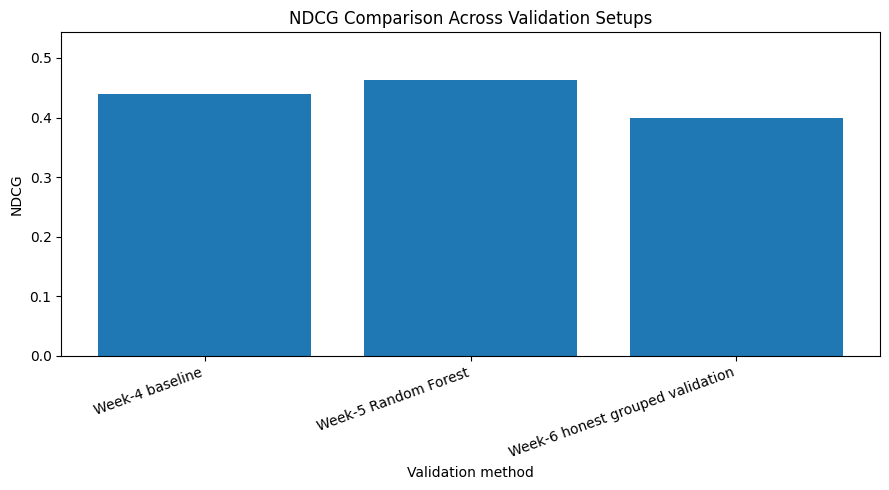


Ranked action queue
-------------------
 action_rank  priority_score                         reason_code  avg_position  impressions  current_ctr  predicted_future_ctr  ctr_opportunity
           1        0.700000 HIGH_PREDICTED_CTR; HIGH_VISIBILITY           2.1         2000     0.075000                  0.08         0.000000
           2        0.484962                     CTR_OPPORTUNITY           8.2          500     0.020000                  0.03         0.016667
           3        0.451880                       REVIEW_SIGNAL           4.5         1000     0.050000                  0.06         0.000000
           4        0.433083                       REVIEW_SIGNAL           6.7         1500     0.053333                  0.05         0.000000
           5        0.000000                       REVIEW_SIGNAL          15.0          100     0.020000                  0.01         0.000000


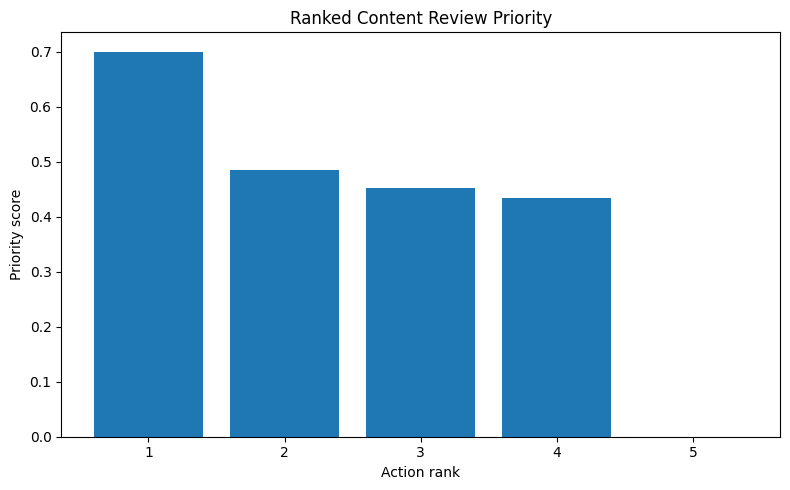


Artifacts created
-----------------
                Artifact                                         Path
Results comparison table work/outputs/capstone_results_comparison.csv
   NDCG comparison chart    work/outputs/capstone_ndcg_comparison.png
     Ranked action queue       work/outputs/capstone_action_queue.csv
   Action priority chart    work/outputs/capstone_action_priority.png

All artifacts created successfully.


In [22]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Create output directory
os.makedirs("work/outputs", exist_ok=True)

# -----------------------------
# 1. Results comparison table
# -----------------------------

comparison = pd.DataFrame({
    "Method": [
        "Week-4 baseline",
        "Week-5 Random Forest",
        "Week-6 honest grouped validation"
    ],
    "NDCG": [
        0.4391,
        0.4629,
        0.4000
    ]
})

print("Results comparison")
print("------------------")
print(comparison.to_string(index=False))

# Save comparison table
comparison_path = "work/outputs/capstone_results_comparison.csv"
comparison.to_csv(comparison_path, index=False)


# -----------------------------
# 2. Results chart
# -----------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    comparison["Method"],
    comparison["NDCG"]
)

plt.ylabel("NDCG")
plt.xlabel("Validation method")
plt.title("NDCG Comparison Across Validation Setups")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, max(comparison["NDCG"]) + 0.08)

plt.tight_layout()

results_chart_path = "work/outputs/capstone_ndcg_comparison.png"
plt.savefig(results_chart_path, dpi=200, bbox_inches="tight")
plt.show()


# -----------------------------
# 3. Action queue artifact
# -----------------------------

action_queue = pd.DataFrame({
    "action_rank": [1, 2, 3, 4, 5],
    "priority_score": [
        0.700000,
        0.484962,
        0.451880,
        0.433083,
        0.000000
    ],
    "reason_code": [
        "HIGH_PREDICTED_CTR; HIGH_VISIBILITY",
        "CTR_OPPORTUNITY",
        "REVIEW_SIGNAL",
        "REVIEW_SIGNAL",
        "REVIEW_SIGNAL"
    ],
    "avg_position": [
        2.1,
        8.2,
        4.5,
        6.7,
        15.0
    ],
    "impressions": [
        2000,
        500,
        1000,
        1500,
        100
    ],
    "current_ctr": [
        0.075000,
        0.020000,
        0.050000,
        0.053333,
        0.020000
    ],
    "predicted_future_ctr": [
        0.08,
        0.03,
        0.06,
        0.05,
        0.01
    ],
    "ctr_opportunity": [
        0.000000,
        0.016667,
        0.000000,
        0.000000,
        0.000000
    ]
})

print("\nRanked action queue")
print("-------------------")
print(action_queue.to_string(index=False))


# Save action queue
queue_path = "work/outputs/capstone_action_queue.csv"
action_queue.to_csv(queue_path, index=False)


# -----------------------------
# 4. Action priority chart
# -----------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    action_queue["action_rank"].astype(str),
    action_queue["priority_score"]
)

plt.xlabel("Action rank")
plt.ylabel("Priority score")
plt.title("Ranked Content Review Priority")

plt.tight_layout()

queue_chart_path = "work/outputs/capstone_action_priority.png"
plt.savefig(queue_chart_path, dpi=200, bbox_inches="tight")
plt.show()


# -----------------------------
# 5. Artifact summary
# -----------------------------

artifact_summary = pd.DataFrame({
    "Artifact": [
        "Results comparison table",
        "NDCG comparison chart",
        "Ranked action queue",
        "Action priority chart"
    ],
    "Path": [
        comparison_path,
        results_chart_path,
        queue_path,
        queue_chart_path
    ]
})

print("\nArtifacts created")
print("-----------------")
print(artifact_summary.to_string(index=False))

artifact_summary.to_csv(
    "work/outputs/capstone_artifact_summary.csv",
    index=False
)

print("\nAll artifacts created successfully.")

# ML-12 — Showcase and Shareable Cuts

## 8. Five-minute demo outline

### 0:00–0:45 — Research question

**Question:** Can search-performance signals be used to rank content pages for human review and identify pages with measurable CTR opportunity?

The practical content problem is prioritization: when many pages need attention, which pages should a content team review first?

This project treats the model as decision-support rather than an automatic content-change system.

### 0:45–1:45 — Data and method

I worked with the FlyRank ML Internship dataset at the content-page observation level.

The workflow used search-performance signals to create a ranking model and action queue. The Week-5 Random Forest was compared with the Week-4 baseline using NDCG.

I then applied a stricter client-grouped validation split in Week 6 to test whether the result remained stable when test clients were not present during training.

### 1:45–2:45 — Show one chart

Show the **NDCG comparison chart**.

The chart compares:

* Week-4 baseline: **0.4391**
* Week-5 Random Forest: **0.4629**
* Week-6 honest grouped validation: **0.4000**

The main point is not simply that the Random Forest had the highest original score. The important research finding is that performance decreased under the stricter grouped validation setup.

### 2:45–3:45 — One honest result

The original Week-5 evaluation observed an NDCG improvement of **0.0238** over the Week-4 baseline.

However, the honest grouped validation produced an NDCG of **0.4000**. This means the original improvement should be treated as a directional result from the original evaluation setup, not as proof of general performance on unseen clients.

The evidence supports further testing and human decision-support rather than a guarantee of future ranking or traffic improvement.

### 3:45–4:30 — One recommendation

The action playbook ranks pages for human review.

The highest-priority row had a priority score of **0.700000** and the reason code **HIGH_PREDICTED_CTR; HIGH_VISIBILITY**.

The second-ranked row had a priority score of **0.484962** and was flagged for **CTR_OPPORTUNITY**.

These rankings tell a content team where to investigate first; they do not automatically prescribe a content change.

### 4:30–5:00 — Close

**Takeaway:** Search-performance signals can be used to create a measurable, ranked review queue, but the validation results show why the queue should remain decision-support.

The next step would be stronger time-aware or repeated validation and human evaluation of whether prioritized pages actually lead to useful content decisions.

---

## 9. Social-post cut

I built a content-prioritization workflow using the FlyRank ML Internship dataset to test whether search-performance signals could rank pages for human review.

The workflow compared a Week-4 baseline with a Week-5 Random Forest and then tested the model under a stricter client-grouped validation setup. The original evaluation observed NDCG of **0.4629 vs 0.4391** for the baseline, while the honest grouped validation measured **0.4000**.

The result is a useful reminder that a stronger initial score is not the same as proven generalization. I turned the analysis into a ranked action queue for human review rather than automatic content changes.

---

## 10. Employer-facing summary

I built a search-content prioritization workflow that uses search-performance signals to rank content pages for human review and identify potential CTR opportunities. The work was developed on the FlyRank ML Internship dataset and included a Random Forest ranking model, baseline comparison, grouped validation, leakage checks, and a ranked action queue. The original evaluation observed NDCG of **0.4629** versus **0.4391** for the baseline, while stricter grouped validation measured **0.4000**, leading me to frame the model as decision-support rather than a guaranteed predictor of future performance.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
